In [1]:
import sys

sys.path.append("../")

import optuna
import pickle
import scipy

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from qiskit.quantum_info import Statevector

from dicke_state_ansatz import DickeStateAnsatz

optuna.logging.set_verbosity(optuna.logging.WARNING)

/home/jvictor/coding/python/quantum-optimization-dicke-states/env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[Paper](https://arxiv.org/abs/2308.00044)

In [13]:
sns.set_theme()

In [2]:
n_shots = [2**i for i in range(13)]
n_iters = [10**i for i in range(4)]
n_calls = sorted([shots*iters for shots in n_shots for iters in n_iters], reverse=False)

## Scenario I

In [5]:
with open(file="../experiments/scenarioI/scenario_info.pkl", mode="rb") as f:
    scenario_info = pickle.load(f)

In [6]:
answer_bitstring = scenario_info["target"]

In [7]:
n = len(answer_bitstring)
k = 4

In [9]:
search_space = []

for i in range(1, k+1):

    qc = DickeStateAnsatz().generate_quantum_circuit(n=n, k=i, measurement=False)
    qc = qc.assign_parameters(parameters=(np.pi/2)*np.ones(qc.num_parameters))
    sv = Statevector(qc)
    search_space.extend(list(sv.probabilities_dict().keys()))

In [10]:
len(search_space) == sum([scipy.special.comb(n,i) for i in range(1, k+1)])

np.True_

In [13]:
m = 1000
columns = ["n_calls", "prob_best_answer"]
data = []

for calls in n_calls:
    counter = 0
    for _ in range(m):
        sample = np.random.choice(search_space, size=calls, replace=True)
        if answer_bitstring in sample:
            counter += 1
    data.append([calls, counter/m])

In [ ]:
df_rs = pd.DataFrame(data=data, columns=columns)
df_rs.to_pickle("../experiments/scenarioI/df_rs.pkl")

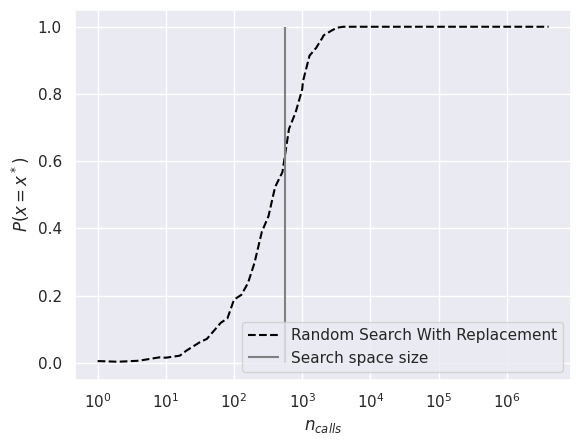

In [ ]:
fig, ax = plt.subplots()

ax.plot(
    df_rs.n_calls, 
    df_rs.prob_best_answer, 
    linestyle="--", 
    color="black", 
    label="Random Search With Replacement"
)
ax.vlines(
    x=len(search_space), 
    ymin=0, 
    ymax=1, 
    color="gray", 
    label="Search space size"
)
ax.set_xscale("log")
ax.legend()
ax.set_xlabel(r"$n_{calls}$")
ax.set_ylabel(r"$P(x=x^*)$")

plt.show()

## Scenario II

In [3]:
with open(file="../experiments/scenarioII/scenario_info.pkl", mode="rb") as f:
    scenario_info = pickle.load(f)

In [4]:
answer_bitstring = scenario_info["target"]

In [5]:
n = len(answer_bitstring)
k_min = 3
k_max = 6

In [7]:
search_space = []

for i in range(k_min, k_max+1):

    qc = DickeStateAnsatz().generate_quantum_circuit(n=n, k=i, measurement=False)
    qc = qc.assign_parameters(parameters=(np.pi/2)*np.ones(qc.num_parameters))
    sv = Statevector(qc)
    search_space.extend(list(sv.probabilities_dict().keys()))

In [8]:
len(search_space) == sum([scipy.special.comb(n,i) for i in range(k_min, k_max+1)])

np.True_

In [10]:
m = 1000
columns = ["n_calls", "prob_best_answer"]
data = []

for calls in n_calls:
    counter = 0
    for _ in range(m):
        sample = np.random.choice(search_space, size=calls, replace=True)
        if answer_bitstring in sample:
            counter += 1
    data.append([calls, counter/m])

In [ ]:
df_rs = pd.DataFrame(data=data, columns=columns)
df_rs.to_pickle("../experiments/scenarioII/df_rs.pkl")

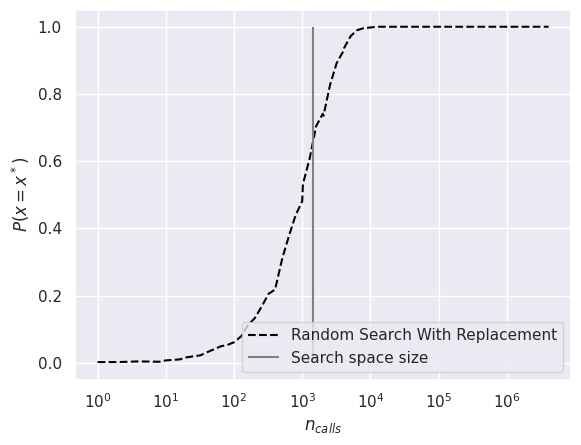

In [14]:
fig, ax = plt.subplots()

ax.plot(
    df_rs.n_calls, 
    df_rs.prob_best_answer, 
    linestyle="--", 
    color="black", 
    label="Random Search With Replacement"
)
ax.vlines(
    x=len(search_space), 
    ymin=0, 
    ymax=1, 
    color="gray", 
    label="Search space size"
)
ax.set_xscale("log")
ax.legend()
ax.set_xlabel(r"$n_{calls}$")
ax.set_ylabel(r"$P(x=x^*)$")

plt.show()

## Scenario III

In [ ]:
with open(file="../experiments/scenarioIII/scenario_info.pkl", mode="rb") as f:
    scenario_info = pickle.load(f)

In [ ]:
answer_bitstring = scenario_info["target"]

In [ ]:
df_rs = pd.DataFrame(data=data, columns=columns)
df_rs.to_pickle("../experiments/scenarioIII/df_rs.pkl")